# Non-interacting bandstructure

taking the 2 orbital model with the |x,up>, |y,down> state and adding a third dimension

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import itertools
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square, extent
from blochK.observable import exp_value_O,conductivity_orbital_resolved, local_dos_QPI, find_Gamma

from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D
from alter_surf.utils3D import projector2layer


#import blochK.utils.

In [2]:


Hparam0 = dict(len_z=10,delta=0.8, tp=0.5, tz=1, PBC= False, mAF=0.3)
H_DLKK = create_H_DLKK_3D(param=Hparam0) #set up Hamiltonian with fixed len_z because it defines n_orbitals



In the 2D DLKK model AM is possible for finite magnetization and $\delta>0$, i.e. the checkerboard pattern which defines an A sublattice (strong hopping in [1,1] direction) and a B sublattice (strong hopping in [1,-1] direction). 
When stacking the model in $z$ direction we have 2 possibilites.
1) AA stacking: stacking plaquettes with strong hoppings on top of each other, i.e. delta_Q_z=0
2) AB stacking: stacking plaquettes with strong hoppings on top of plaquttes with weak hoppings, i.e. delta_Q_z $=\pi$

The magnetization in $z$-direction can now also be alternating Q_z $=\pi$ or even Q_z $=0$. That gives us 4 cases:
1)  delta_Q_z $=0$, Q_z $=0$: AM (same symmetries as 2D DLKK model)
2)  delta_Q_z $=0$, Q_z $=\pi$: AFM (spin flip + $z$-translation is a symmetry)
3)  delta_Q_z $=\pi$, Q_z $=0$: AFM (spin flip + $z$-translation + $x$-translation is a symmetry)
4)  delta_Q_z $=\pi$, Q_z $=\pi$: AM (all up sites have strong hopping in [11] direction)

The state 2. is a good starting point. It can be stabilized in a 3D Hubbard model.

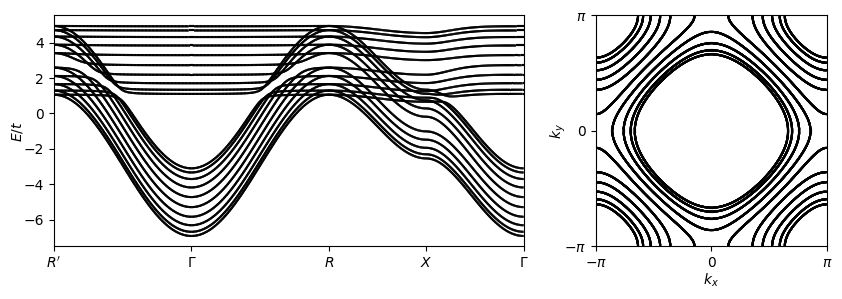

In [3]:
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))

#some special points of the brillouin zone

labels = ["R'",'\Gamma','R',"X",'\Gamma']

coloring_operator = H_DLKK.operator.spin

cmap = 'bwr'

plot_bandstruc(ax,H_DLKK,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap)
plot_FS(ax1,H_DLKK,coloring_operator=coloring_operator,cmap=cmap)


## Plotting the spectral function

In [28]:
Lk = 40 #number of k-points in each direction

# Define the k-point grid
ks = sample_square(Lk)
#Diagonalize Hamiltonian
es,psis = H_DLKK.diagonalize(*ks)


def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin=''):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,vmin=vmin,vmax=vmax)
    return im


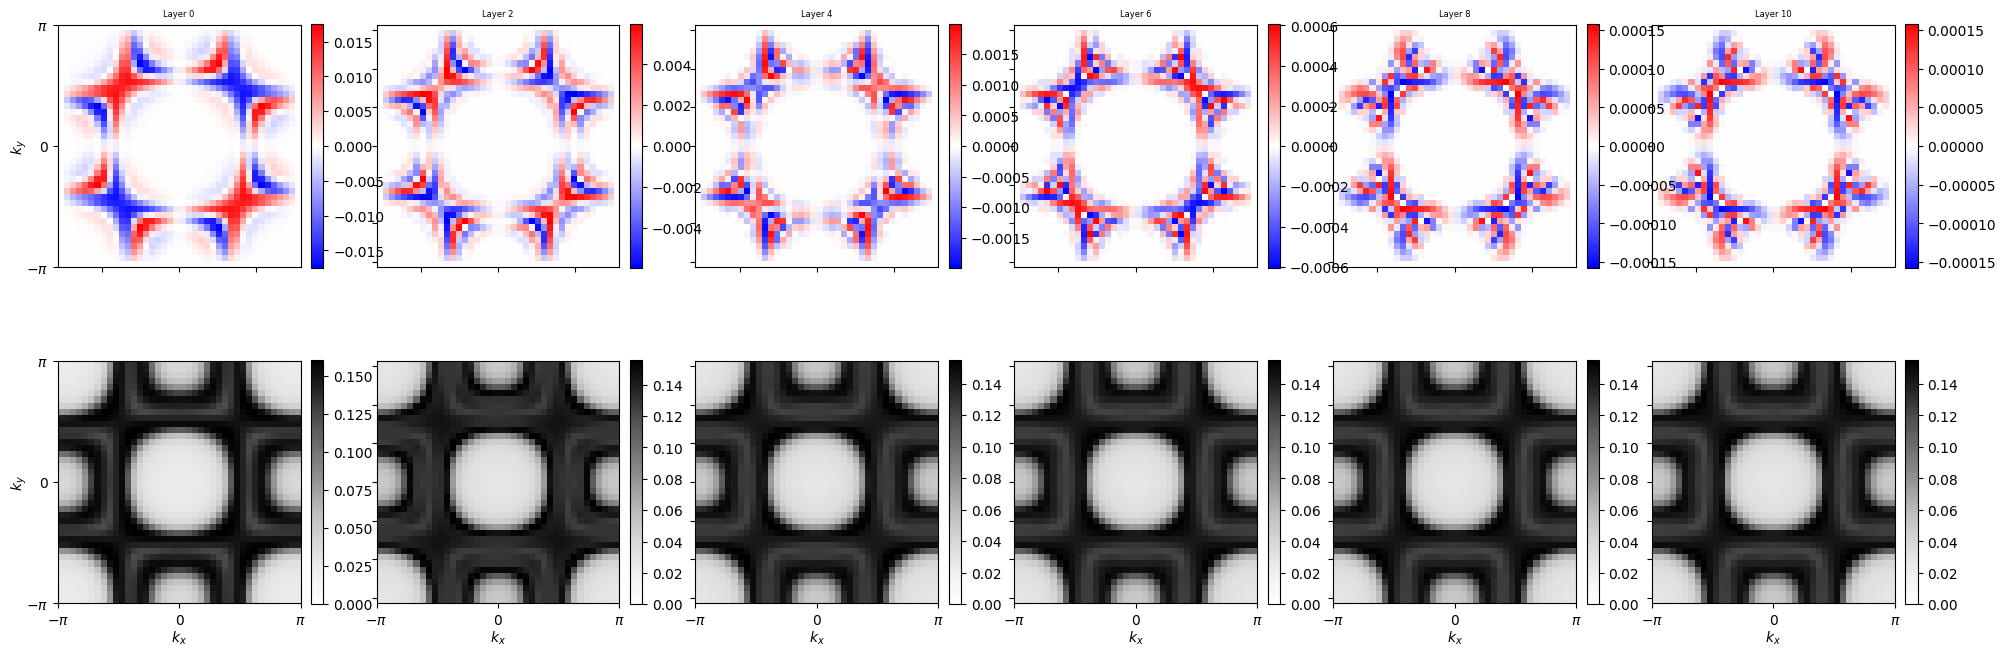

In [29]:
Gamma = find_Gamma(es)
len_z = Hparam0['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z//2,6,dtype=int)


#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    
    vmax_spin = np.abs(spectral_density_spin).max()
    vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)


## Spin conductivity

In [30]:
#setting parameters
Lk = 40 #number of k-points in each direction

# Calculate spin conductivity
cond_tensor = conductivity_orbital_resolved(H_DLKK,Lk=Lk,optimize='path') #.shape=(localH,x,y)

In [31]:
#1) way of dealing with this tensor: smart reshaping and then contracting all unwanted indices
n_layers = 2 #sum always n_layers layers up
cond_tensor2 = np.reshape(cond_tensor,(len_z,2,2,2,2)) #.shape=(layer,spin,sublattice,x,y)
cond_tensor2 = cond_tensor2.reshape(-1,n_layers,2,2,2,2) #.shape=(layer/n_layers,n_layers,sublattice,spin,x,y)
cond_xx = np.sum(cond_tensor2[:,:,:,:,0,0],axis=(1,3)) #.shape=(layer/n_layers,spin)
spin_cond_xx = cond_xx[:,0]-cond_xx[:,1] #difference of spin indices
cond0_xx = cond_xx[:,0]+cond_xx[:,1] #total cond: sum of spin indices
#indices is fixed by n_layers
layers = np.arange(0,len_z+1-n_layers,n_layers)


# #2) way of dealing with this tensor: construct full observable and then contract (slower but does't matter)
# #we can compute pairs (0,1), (1,2), (2,3), ...
# spin_cond00 = []; cond00 = []
# layers = np.arange(0,param['len_z']-1,1) #specify 

# for layer in layers:
#     proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
#     Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
#     spin_cond00.append(np.sum(Spin_op_layer*cond_tensor[:,0,0]))
#     cond00.append(np.sum(np.kron(proj_2layers,np.ones(4))*cond_tensor[:,0,0]))

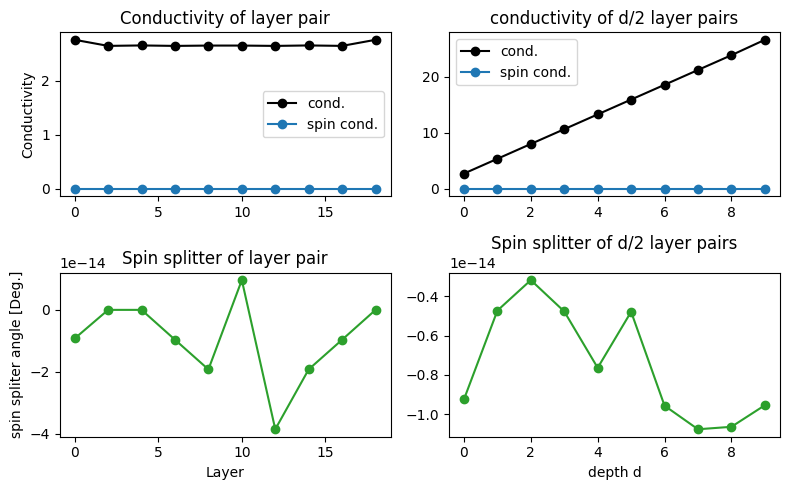

In [32]:
fig,axs = plt.subplots(2,2,figsize=(8,5))

#layer resolved
axs[0,0].set_title('Conductivity of layer pair')
axs[0,0].plot(layers,cond0_xx,'ko-',label='cond.')
axs[0,0].plot(layers,spin_cond_xx,'o-',label='spin cond.')
axs[0,0].set_ylabel('Conductivity')
axs[0,0].legend()

axs[1,0].set_title('Spin splitter of layer pair')
axs[1,0].plot(layers,2*np.arctan(spin_cond_xx/cond0_xx)*180/pi,'o-',color='C2')
axs[1,0].set_xlabel('Layer')
axs[1,0].set_ylabel('spin spliter angle [Deg.]')

#layer summed
lz2 = len_z//2
xs = np.arange(0,lz2)
axs[0,1].set_title('conductivity of d/2 layer pairs')
axs[0,1].plot(xs,np.cumsum(cond0_xx[:lz2]),'ko-',label='cond.')
axs[0,1].plot(xs,np.cumsum(spin_cond_xx[:lz2]),'o-',label='spin cond.')
axs[0,1].legend()

axs[1,1].set_title('Spin splitter of d/2 layer pairs')
axs[1,1].plot(xs,2*np.arctan(np.cumsum(spin_cond_xx[:lz2])/np.cumsum(cond0_xx[:lz2]))*180/pi,'o-',color='C2')
axs[1,1].set_xlabel('depth d')


plt.tight_layout()


## Checking the spectral density along a 1D path

Let's look at the spectral properties along the path $(0,0)$ to $(\pi,\pi)$. Then we can see efficiently how spin degneracy is restored

In [34]:
Lk = 200 #number of k-points in each direction

# Define the k-point grid
kxs = np.linspace(0,pi,Lk)
kys = kxs
#Diagonalize Hamiltonian
es,psis = H_DLKK.diagonalize(kxs,kys)

Gamma = 1e-2

#compute spectral density
layers = np.arange(0,Hparam0['len_z']//2,1,dtype=int)
spin_spec_dens = []
spec_dens = []
for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spin_spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

    #computespectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

spin_spec_dens = np.array(spin_spec_dens)
spec_dens = np.array(spec_dens)


ValueError: operands could not be broadcast together with shapes (80,200,80) (16,) 

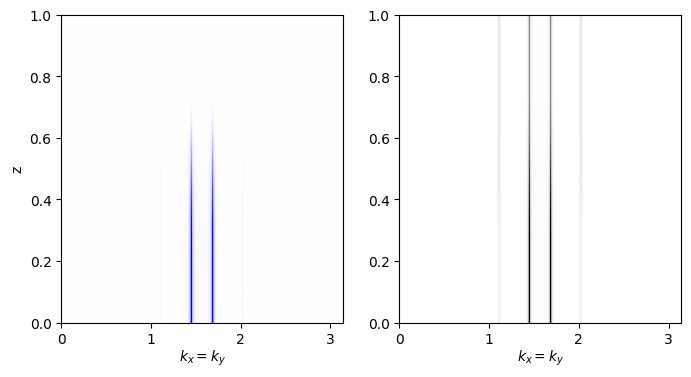

In [ ]:
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(8,4))

ax1.set_xlabel('$k_x=k_y$',labelpad=1)
ax2.set_xlabel('$k_x=k_y$',labelpad=1)
ax1.set_ylabel('z')

vmax = np.abs(spin_spec_dens).max()
im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax,aspect='auto')
im2 = ax2.imshow(spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='Greys',vmin=0,vmax=spec_dens.max(),aspect='auto')


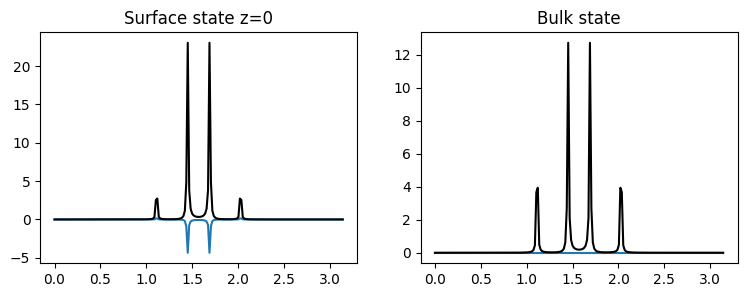

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(9,3))

axs[0].set_title('Surface state z=0')
axs[0].plot(kxs,spin_spec_dens[0],'-')
axs[0].plot(kxs,spec_dens[0],'k-')

axs[1].set_title('Bulk state')
axs[1].plot(kxs,spin_spec_dens[-1],'-')
axs[1].plot(kxs,spec_dens[-1],'k-')

Text(0, 0.5, 'integrated spin density')

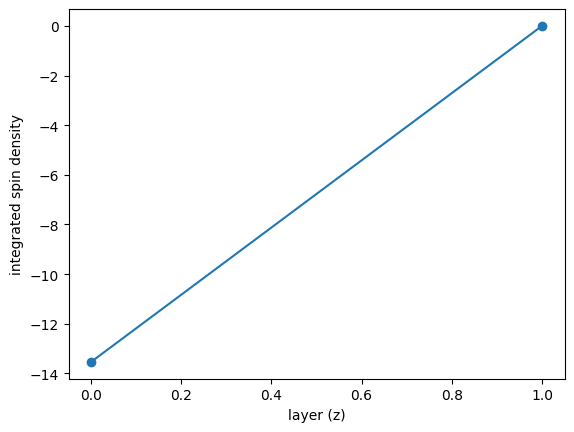

In [ ]:
plt.plot(layers,spin_spec_dens.sum(axis=-1),'o-')
plt.xlabel('layer (z)')
plt.ylabel('integrated spin density')